# Notebook 02: Agents in Grid World

Trong notebook này, chúng ta sẽ cài đặt và so sánh ba loại agent:
- Reflex agent (tác nhân phản xạ)
- Goal-based agent (tác nhân dựa trên mục tiêu)
- Utility-based agent (tác nhân dựa trên hàm hữu dụng)

Môi trường minh họa là **Grid World**.

In [35]:
from collections import deque

def print_matrix(mat, title):
    print(title)
    for row in mat:
        print("  ".join(f"{val}" for val in row))
    print()

def bfs():
    q = deque([((0,0), [(0,0)])])
    visited = [[False]*n for _ in range(n)]
    visited[0][0] = True

    while q:
        (x, y), path = q.popleft()
        if (x, y) == (n-1, n-1):
            return path
        for dx, dy in dirs:
            nx, ny = x+dx, y+dy
            if 0 <= nx < n and 0 <= ny < n and maze[nx][ny] == 1 and not visited[nx][ny]:
                visited[nx][ny] = True
                q.append(((nx, ny), path+[(nx,ny)]))
    return None

n = 5
obstacles = [              (0,2),        (0,4),
             (1,0),                      
                           (2,2),        (2,4),
                    (3,1),
                                  (4,3)]

maze = [[1]*n for _ in range(n)]
for x, y in obstacles:
    maze[x][y] = 0

dirs = [(1,0), (-1,0), (0,1), (0,-1)]
print_matrix(maze, "Maze gốc (1=đi được, 0=vật cản):")

path = bfs()
print("Đường đi ngắn nhất:", path)

result = [[0]*n for _ in range(n)]
if path:
    for (x, y) in path:
        result[x][y] = 1

print_matrix(result, "Maze kết quả (đường đi ngắn nhất=1):")



Maze gốc (1=đi được, 0=vật cản):
1  1  0  1  0
0  1  1  1  1
1  1  0  1  0
1  0  1  1  1
1  1  1  0  1

Đường đi ngắn nhất: [(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 4), (4, 4)]
Maze kết quả (đường đi ngắn nhất=1):
1  1  0  0  0
0  1  1  1  0
0  0  0  1  0
0  0  0  1  1
0  0  0  0  1



In [36]:
import time
import random
import keyboard
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output, display


class GridWorld:
    def __init__(self, size=5, start=(0,0), goal=(4,4), obstacles=[]):
        self.size = size
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        self.reset()

    def reset(self):
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action):
        x, y = self.agent_pos
        if action == 'UP':
            new_pos = (x-1, y)
        elif action == 'DOWN':
            new_pos = (x+1, y)
        elif action == 'LEFT':
            new_pos = (x, y-1)
        elif action == 'RIGHT':
            new_pos = (x, y+1)
        else:
            new_pos = self.agent_pos

        # Kiểm tra biên và chướng ngại vật
        if (0 <= new_pos[0] < self.size and 0 <= new_pos[1] < self.size and new_pos not in self.obstacles):
            self.agent_pos = new_pos
        
        reward = -1
        done = False
        if self.agent_pos == self.goal:
            reward = 10
            done = True
        return self.agent_pos, reward, done

    def render(self, show=True):
        grid = np.zeros((self.size, self.size))
        for obs in self.obstacles:
            grid[obs] = -1
        grid[self.goal] = 2
        grid[self.agent_pos] = 1

        fig, ax = plt.subplots()
        ax.imshow(grid, origin='upper')
        ax.set_title('GridWorld')
        ax.axis('off')

        if show:
            plt.show()
        return fig, ax

In [37]:
class bestSolver:
    def __init__(self, env):
        self.env = env

    def act(self):
        possible_actions = ['UP','DOWN','LEFT','RIGHT']

In [38]:
class RandomAgent:
    def __init__(self, env):
        self.env = env
    
    def act(self):
        return random.choice(['UP','DOWN','LEFT','RIGHT'])

In [ ]:
class ReflexAgent:
    def __init__(self, env):
        self.env = env

    def act(self):
        # Chọn hành động ngẫu nhiên nhưng tránh va chạm
        possible_actions = ['UP','DOWN','LEFT','RIGHT']
        random.shuffle(possible_actions)
        for action in possible_actions:
            x, y = self.env.agent_pos
            if action == 'UP': new_pos = (x-1, y)
            elif action == 'DOWN': new_pos = (x+1, y)
            elif action == 'LEFT': new_pos = (x, y-1)
            elif action == 'RIGHT': new_pos = (x, y+1)
            else: new_pos = (x, y-1)
            if (0 <= new_pos[0] < self.env.size and 0 <= new_pos[1] < self.env.size and new_pos not in self.env.obstacles):
                return action
        return 'UP'

In [ ]:
class GoalBasedAgent:
    def __init__(self, env):
        self.env = env

    def act(self):
        # Di chuyển tham lam hướng về goal
        ax, ay = self.env.agent_pos
        gx, gy = self.env.goal
        if gx > ax:
            return 'DOWN'
        elif gx < ax:
            return 'UP'
        elif gy > ay:
            return 'RIGHT'
        elif gy < ay:
            return 'LEFT'
        else:
            return random.choice(['UP','DOWN','LEFT','RIGHT'])

In [ ]:
class UtilityBasedAgent:
    def __init__(self, env):
        self.env = env

    def act(self):
        # Chọn hành động dựa trên hàm hữu dụng
        actions = ['UP','DOWN','LEFT','RIGHT']
        best_action = None
        best_utility = -float('inf')
        for action in actions:
            x, y = self.env.agent_pos
            if action == 'UP':
                new_pos = (x-1, y)
            elif action == 'DOWN':
                new_pos = (x+1, y)
            elif action == 'LEFT':
                new_pos = (x, y-1)
            elif action == 'RIGHT':
                new_pos = (x, y+1)
            else:
                new_pos = self.agent_pos

            if (0 <= new_pos[0] < self.env.size and 0 <= new_pos[1] < self.env.size and new_pos not in self.env.obstacles):
                # Utility = - khoảng cách đến goal
                gx, gy = self.env.goal
                utility = - (abs(new_pos[0]-gx) + abs(new_pos[1]-gy))
                if utility > best_utility:
                    best_utility = utility
                    best_action = action
        return best_action if best_action else random.choice(actions)

In [ ]:
def run_episode(env, agent, max_steps=50):
    pos = env.reset()
    done = False
    step = 0
    trajectory = [pos]
    for _ in range(max_steps):
        action = agent.act()
        pos, reward, done = env.step(action)
        trajectory.append(pos)
        step += 1
        if done:
            break
    print(f"Step: {step}")
    return trajectory

In [19]:
def animate_episode(env, agent, max_steps=50, delay=0.3):
    pos = env.reset()
    done = False
    steps = 0
    trajectory = [pos]
    while not done and steps < max_steps:
        action = agent.act()
        pos, reward, done = env.step(action)
        trajectory.append(pos)
        clear_output(wait=True)
        fig, ax = env.render(show=False)
        display(fig)
        plt.close(fig)
        time.sleep(delay)
        steps += 1
    return trajectory, steps, done


In [ ]:
env = GridWorld(size=10, start=(0,0), goal=(9,9), 
obstacles=[(1,1), (2,2), (3,1), (4,4), (5,6), (6,5), (7,8), (8,9), (9,7)]
)

env = GridWorld(
    size=5,
    start=(0,0),
    goal=(4,4),
    obstacles=[(1,1), (2,2), (3,1)]
)

agents = {
    'Random': RandomAgent(env),
    'Reflex': ReflexAgent(env),
    'GoalBased': GoalBasedAgent(env),
    'UtilityBased': UtilityBasedAgent(env)
}

"""
    Random: random; random
    Reflex: 0; random
    GoalBased: số bước còn lại - số bước đã đi trước khi gặp vật cản; 0
    UtilityBased: 0; max_step - 
   
"""

'\n    Random: random; random\n    Reflex: 0; random\n    GoalBased: số bước còn lại - số bước đã đi trước khi gặp vật cản; 0\n    UtilityBased: 0; max_step - \n\n'

In [41]:
for name, agent in agents.items():
    print(f"\nRunning {name} agent (animation)...")
    traj = run_episode(env, agent, max_steps=99)
    print(f"last_pos={traj[-1]}")
    # env.render()


Running Reflex agent (animation)...
Step: 18
last_pos=(4, 4)


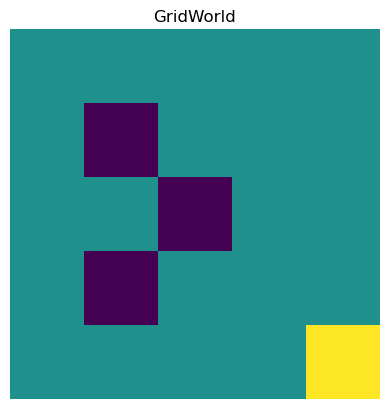

In [42]:
for name, agent in agents.items():
    print(f"Running {name} agent (animation)...")    
    traj, steps, done = animate_episode(env, agent, max_steps=60, delay=0.01)

## 📝 Bài tập cho sinh viên

1. **Thay đổi môi trường**
   - Thử tạo lưới có kích thước khác (ví dụ 7x7, 10x10).
   - Thêm/bớt chướng ngại vật và quan sát sự thay đổi trong quỹ đạo di chuyển.

2. **Điều chỉnh thuật toán tác tử**
   - Bổ sung thêm một tác tử **RandomAgent**: luôn chọn hành động ngẫu nhiên.
   - So sánh quỹ đạo và độ dài đường đi của RandomAgent với các tác tử khác.

3. **Đánh giá hiệu quả**
   - Tính tổng số bước mà mỗi tác tử đi từ start đến goal.
   - Ghi nhận số lần tác tử va phải chướng ngại vật hoặc quay lại ô cũ.
   
4. **Nâng cấp tác tử**
   - Thiết kế một **LearningAgent** đơn giản dùng Q-learning hoặc SARSA để học cách di chuyển đến goal.
   - So sánh hiệu quả của LearningAgent với UtilityBasedAgent.

5. **Quan sát trực quan**
   - Cập nhật hàm `render()` để hiển thị thêm:
     - Quỹ đạo các bước đi.
     - Số bước đã đi.
     - Ký hiệu khác biệt cho start (S), goal (G), chướng ngại vật (X), tác tử (A).
   - Vẽ đồ thị (sử dụng matplotlib) biểu diễn số bước cần thiết của mỗi tác tử.

6. **Thảo luận**
   - Khi môi trường thay đổi, tác tử nào thích nghi tốt nhất? Vì sao?
   - Ưu/nhược điểm của từng loại tác tử trong thực tế (ví dụ: robot hút bụi, xe tự lái).
